In [1]:
"""Smoke-test for the Rossmann store sales forecasting pipeline.

Generates a small synthetic dataset with a strong, easy-to-fit weekly pattern,
runs the full feature-engineering → nested CV pipeline, prints test-set metrics,
and plots real vs predicted sales for the last outer fold.

Usage: conda run -n rossmann python test_pipeline.py
"""

import os
import logging
import warnings

import optuna
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import src.constants as C

from matplotlib import cm
from src.features import make_features, make_targets, attach_store_data
from src.preprocessing import drop_null_targets
from src.engine.cv import TimeSeriesCV
from src.engine.metrics import compute_metrics
from src.engine import utils, hypertuning

from src import synthetic

FORECAST_HORIZON = 5

os.makedirs(C.LOG_DIR, exist_ok=True)
logging.basicConfig(level=logging.INFO, 
                    filename=os.path.join(C.LOG_DIR, "test_pipeline.log"),
                    format="%(levelname)s  %(message)s")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

logger = logging.getLogger(__name__)



from pandas.tseries.offsets import DateOffset

def add_days_to_offset(offset: DateOffset, days_to_add: int) -> DateOffset:
    """
    Adds a specified number of days to a given DateOffset, returning a new DateOffset.
    Args:
        offset (DateOffset): The original DateOffset to which days will be added.
        days_to_add (int): The number of days to add to the original DateOffset.

    Returns:
        DateOffset: A new DateOffset that represents the original offset plus the added days.
    """
    kwds = offset.kwds.copy()
    kwds['days'] = kwds.get('days', 0) + days_to_add
    return DateOffset(**kwds)

c:\Users\m_kal\Downloads\rossmann_store_sales\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Synthetic Data

Strong deterministic weekly + trend signal so the model can overfit easily and produce low errors.

 DayOfWeek  Open  Promo StateHoliday  SchoolHoliday      Sales StoreType Assortment  CompetitionDistance CompetitionSinceDate Promo2SinceDate  Promo2
         2     1      0            0              0 467.320508         a          a                500.0           2012-03-01      2012-06-01       1
         2     1      0            0              0 617.320508         b          a               1200.0           2011-06-01             NaT       0
         2     1      0            0              0 767.320508         c          b                800.0           2013-01-01      2013-03-01       0
         3     1      0            0              0 467.470508         a          a                500.0           2012-03-01      2012-06-01       1
         3     1      0            0              0 617.470508         b          a               1200.0           2011-06-01             NaT       0


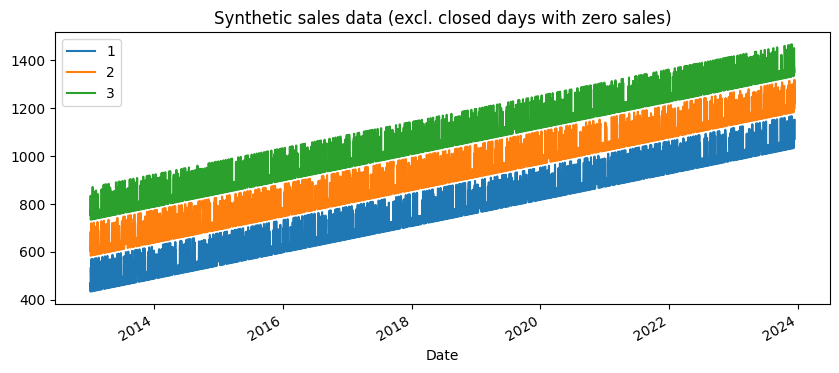

In [2]:
stores = synthetic.store_data()
train = synthetic.sales_data()
df  = attach_store_data(train, stores)
df.sort_values(['Date', 'Store'], inplace=True)  # Sort by date and store (ascending -> from earliest to latest) for lag features
df.set_index(["Date", "Store"], inplace=True)

cv_config = {
    "n_outer_splits":   C.N_OUTER_SPLITS,
    "n_inner_splits":   C.N_INNER_SPLITS,
    "forecast_horizon": FORECAST_HORIZON, #C.FORECAST_HORIZON,
    "inner_train_size": 1000, #C.INNER_TRAIN_SIZE,
}

cv_config["outer_train_size"] = (cv_config["n_inner_splits"] + 1) * cv_config["forecast_horizon"] + cv_config["inner_train_size"]


study_config = {
    "storage_url":           C.STORAGE_URL,
    "n_trials":              C.NUM_TRIALS,
    "n_startup_trials":      C.NUM_STARTUP_TRIALS,
    "n_jobs":                C.NUM_JOBS,
    "seed":                  C.SEED,
    "xgb_constants":         C.XGB_CONSTANTS,
    "early_stopping_rounds": C.EARLY_STOPPING_ROUNDS,
    "num_boost_rounds":      C.NUM_BOOST_ROUNDS,
    "monitor_periods":       C.MONITOR_PERIODS,
    "hyperparameters":       C.HYPERPARAMETERS,
    "log_dir":               C.LOG_DIR,
}

print(df.head(5).to_string(index=False))

(
    df
    .loc[df['Sales'] > 0]
    .reset_index()
    .set_index("Date")
    .groupby("Store")["Sales"]
    .plot(figsize=(10, 4),
          title="Synthetic sales data (excl. closed days with zero sales)",
          legend=True)
)

plt.savefig(os.path.join(C.LOG_DIR, "training_set.png"))

In [3]:
# Make sure to add the forecast horizon to the lags, diffs, and rolling window offsets
# This ensures that the features are correctly aligned with the target variable, which is shifted by the forecast horizon.
# If we don't do this, the model will be trained on features that are not available at the time of prediction, leading \
# to data leakage and overly optimistic performance metrics.

lags = [add_days_to_offset(l, FORECAST_HORIZON) for l in C.LAGS]
diffs = [add_days_to_offset(d, FORECAST_HORIZON) for d in C.DIFFS]
rolling_windows = {}
for window, offsets in C.ROLL_WINDOWS.items():
    adjusted_offsets = [add_days_to_offset(offset, FORECAST_HORIZON) for offset in offsets]
    rolling_windows[window] = adjusted_offsets

Since the Rossmann test horizon is 6 weeks (42 days), any historical feature you use must look back at least 42 days. If you use a 42-day lag, you will always have real data available, even on the very last day of the prediction horizon.

Assume 1 store with 1 month of data. 30 rows. i need to predict 5 days into the future. How do X and y look like?

* [ Day 1 to Day 5 ]  -->  Used only to create lags for later days.
* [ Day 6 to Day 30 ] -->  Your actual Training Rows.

| Row | Date (X) | DayOfWeek (X) | Sales_Lag_5 (X) | ... | Actual Sales (y - Target) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 1 | Day 6 | Friday | Sales from Day 1 | ... | $5,000 |
| 2 | Day 7 | Saturday | Sales from Day 2 | ... | $6,200 |
| 3 | Day 8 | Sunday | Sales from Day 3 | ... | $0 (Closed) |
| ... | ... | ... | ... | ... | ... |
| 25 | Day 30 | Friday | Sales from Day 25 | ... | $5,400 |

In [4]:
""" 
# Preprocessing steps:
# 1. Overwrite zero sales for Sundays (closed) with interpolated values based on adjacent open days, 
#    to allow feature creation for those days (e.g. lags, rolls, diffs, forecast horizon)
# 2. First-order differencing on the Sales column to make the series more stationary
# 3. Create features and targets for the whole dataset
# 4. Drop rows with null targets (i.e. those that don't have enough history
#    to create all requested lags, rolls, diffs, and/or forecast horizon)

df_processed = df.copy()
df_processed['Sales'] = (
    utils.overwrite_closed_sales(df_processed['Sales'], mode='interpolate')
    .groupby(level='Store')
    .diff()
)
X = make_features(df_processed, lags, rolling_windows, diffs)
y = make_targets(df_processed['Sales'], FORECAST_HORIZON)
X, y = drop_null_targets(X, y)

cv = TimeSeriesCV(n_splits=cv_config["n_outer_splits"],
                  horizon=cv_config["forecast_horizon"],
                  train_size=cv_config["outer_train_size"])

for fold, (train_ix, test_ix) in enumerate(cv.split(X, y), start=1):
    logger.info(f"Outer fold {fold}/{cv_config['n_outer_splits']} starting...")

    study_name = f"fold_{fold}"
    X_train, y_train = X.iloc[train_ix], y.iloc[train_ix]
    X_test, y_test = X.iloc[test_ix], y.iloc[test_ix]
    
    # Run Optuna hyperparameter tuning with nested CV in the inner loop
    logger.info(f"Running hyperparameter tuning ({study_config['n_trials']} trials)...")
    hypertuning.optimize(study_name, X_train, y_train, {**cv_config, **study_config})

    # Retrain final model on the entire outer fold training set with the best hyperparameters
    logger.info(f"Retraining model with the best hyperparameters...")
    study = optuna.load_study(study_name=study_name, storage=study_config["storage_url"])
    booster = hypertuning.refit(X_train, y_train, study.best_trial, study_config)
    
    logger.info(f"Evaluating final model on outer fold {fold} test set...")
    preds = utils.predict(booster, X_test)

    # Inverse first-order differencing to get predictions back on the original scale
    origin_index = preds.index.droplevel('Forecast Date')
    anchors = (utils.overwrite_closed_sales(df['Sales'], mode='interpolate')
               .loc[origin_index]
               .set_axis(preds.index))
    preds = anchors + preds.groupby(level=['Date', 'Store']).cumsum()
    
    # Log metrics and artifacts
    actuals = utils.retrieve_sales(df['Sales'], preds.index)
    metrics = compute_metrics(actuals.values, preds.values)
    logger.info(f"Test set metrics for fold {fold}: {metrics}")
    
    booster_file = os.path.join(study_config["log_dir"], study_name, "model.ubj")
    preds_file = os.path.join(study_config["log_dir"], study_name, "predictions.csv")
    booster.save_model(booster_file)
    preds.to_csv(preds_file)

    break
"""

' \n# Preprocessing steps:\n# 1. Overwrite zero sales for Sundays (closed) with interpolated values based on adjacent open days, \n#    to allow feature creation for those days (e.g. lags, rolls, diffs, forecast horizon)\n# 2. First-order differencing on the Sales column to make the series more stationary\n# 3. Create features and targets for the whole dataset\n# 4. Drop rows with null targets (i.e. those that don\'t have enough history\n#    to create all requested lags, rolls, diffs, and/or forecast horizon)\n\ndf_processed = df.copy()\ndf_processed[\'Sales\'] = (\n    utils.overwrite_closed_sales(df_processed[\'Sales\'], mode=\'interpolate\')\n    .groupby(level=\'Store\')\n    .diff()\n)\nX = make_features(df_processed, lags, rolling_windows, diffs)\ny = make_targets(df_processed[\'Sales\'], FORECAST_HORIZON)\nX, y = drop_null_targets(X, y)\n\ncv = TimeSeriesCV(n_splits=cv_config["n_outer_splits"],\n                  horizon=cv_config["forecast_horizon"],\n                  train_s

In [32]:
import optuna
import xgboost as xgb

from src.engine.callbacks import BoosterCollector
from src.engine import utils

stores = synthetic.store_data(n_stores=3)
train = synthetic.sales_data(n_stores=3, days=2500)
df  = attach_store_data(train, stores)
df.sort_values(['Date', 'Store'], inplace=True)  # Sort by date and store (ascending -> from earliest to latest) for lag features
df.set_index(["Date", "Store"], inplace=True)
FORECAST_HORIZON = 1
INNER_TRAIN_SIZE = 1000


cv_config = {
    "n_outer_splits":   C.N_OUTER_SPLITS,
    "n_inner_splits":   C.N_INNER_SPLITS,
    "forecast_horizon": FORECAST_HORIZON, #C.FORECAST_HORIZON,
    "inner_train_size": INNER_TRAIN_SIZE, #C.INNER_TRAIN_SIZE,
}

cv_config["outer_train_size"] = (cv_config["n_inner_splits"] + 1) * cv_config["forecast_horizon"] + cv_config["inner_train_size"]

# Feature engineering settings
LAGS = []
for d in [1, 2, 3, 4, 5, 6, 7, 14, 30, 60, 90]:
    LAGS.append(DateOffset(days=d))

DIFFS = []#[DateOffset(days=1), DateOffset(months=1), DateOffset(months=3), DateOffset(months=6)]
ROLL_WINDOWS = {}

lags = [add_days_to_offset(l, FORECAST_HORIZON) for l in LAGS]
rolling_windows = {}

df_processed = df.copy()
df_processed['Sales'] = (
    utils.overwrite_closed_sales(df_processed['Sales'], mode='interpolate')
    .groupby(level='Store')
    .diff()
)

X = make_features(df_processed, lags, rolling_windows, diffs)
y = make_targets(df_processed['Sales'], FORECAST_HORIZON)
#y = df_processed['Sales'].copy()
non_null_targets = ~y.isnull()
X, y = X[non_null_targets], y[non_null_targets]

params = {
'max_depth': 6,
'learning_rate': 1e-3,
'subsample': 0.6,
'colsample_bytree': 0.6,
'min_child_weight': 1,
'reg_alpha': 0,
'reg_lambda': 1,
'gamma': 0,
}
all_params = {**study_config["xgb_constants"], **params}
metric = study_config["xgb_constants"]["eval_metric"]

# Run CV and pruning in a single call to XGBoost's cv function
booster_collector = BoosterCollector()
callbacks = [
    xgb.callback.EvaluationMonitor(show_stdv=True, period=study_config["monitor_periods"]),
    #xgb.callback.EarlyStopping(rounds=study_config["early_stopping_rounds"]),
    #XGBoostPruningCallback(trial, observation_key=f"test-{metric}"),
    # The observation_key in the pruning callback reads from XGBoost's internal evals_log
    # dict (keyed as "test-<metric>") - not from the final DataFrame column names ("test-<metric>-mean").
    booster_collector,
]

inner_cv = TimeSeriesCV(n_splits=50,#cv_config["n_inner_splits"],
                        horizon=cv_config["forecast_horizon"],
                        train_size=cv_config["inner_train_size"])

dtrain = xgb.DMatrix(X, label=y, enable_categorical=True)
num_boost_round = study_config["num_boost_rounds"]
folds = list(inner_cv.split(X))

history = xgb.cv(params=all_params,
                 dtrain=dtrain,
                 num_boost_round=3000,
                 folds=folds,
                 metrics=[metric],
                 callbacks=callbacks,
                 verbose_eval=False,
                 seed=study_config["seed"])


score = history[f"test-{metric}-mean"].min()

[0]	train-rmse:55.02596+0.10570	test-rmse:48.21747+28.74780
[100]	train-rmse:52.62807+0.09528	test-rmse:46.67120+27.23355
[200]	train-rmse:50.44779+0.08657	test-rmse:45.31470+25.85739
[300]	train-rmse:48.49400+0.07726	test-rmse:44.12999+24.65954
[400]	train-rmse:46.95406+0.07124	test-rmse:43.22220+23.78861
[500]	train-rmse:45.44244+0.06499	test-rmse:42.40842+22.88841
[600]	train-rmse:44.07081+0.05952	test-rmse:41.71266+22.01628
[700]	train-rmse:42.78786+0.05524	test-rmse:41.14233+21.07470
[800]	train-rmse:41.70180+0.05079	test-rmse:40.70334+20.23943
[900]	train-rmse:40.75171+0.04696	test-rmse:40.33296+19.56609
[1000]	train-rmse:39.90467+0.04433	test-rmse:40.02176+18.98479
[1100]	train-rmse:39.14369+0.04275	test-rmse:39.75179+18.48332
[1200]	train-rmse:38.46844+0.04042	test-rmse:39.54646+18.06027
[1300]	train-rmse:37.83995+0.03871	test-rmse:39.37157+17.69060
[1400]	train-rmse:37.25771+0.03757	test-rmse:39.20162+17.35318
[1500]	train-rmse:36.74947+0.03738	test-rmse:39.09934+17.10759
[160

<Axes: title={'center': 'XGBoost CV (rmse = 38.6566)'}>

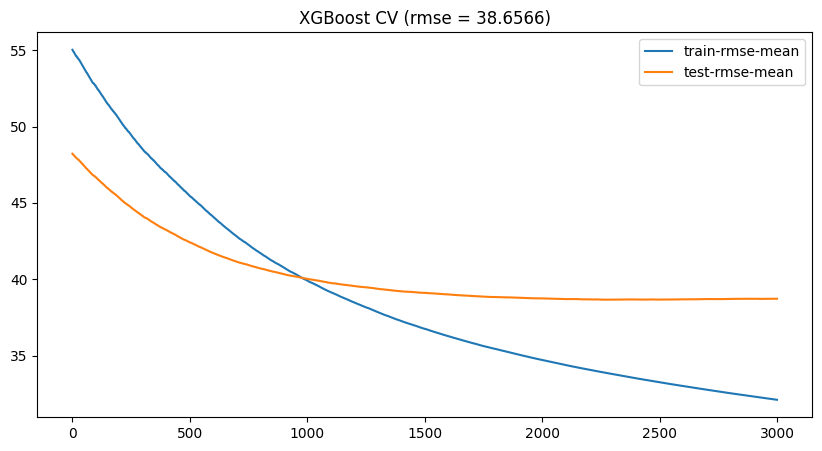

In [33]:
history[[f"train-{metric}-mean", f"test-{metric}-mean"]].plot(figsize=(10, 5), title=f"XGBoost CV ({metric} = {score:.4f})")

In [28]:
inner_cv = TimeSeriesCV(n_splits=50,
                        horizon=cv_config["forecast_horizon"],
                        train_size=cv_config["inner_train_size"])


for train_ix, test_ix in inner_cv.split(X, y):
    min_train_date = X.iloc[train_ix].index.get_level_values('Date').min()
    max_train_date = X.iloc[train_ix].index.get_level_values('Date').max()
    min_test_date = X.iloc[test_ix].index.get_level_values('Date').min()
    max_test_date = X.iloc[test_ix].index.get_level_values('Date').max()
    print(f"Train: {min_train_date.date()} to {max_train_date.date()} ({len(train_ix)} samples)| Test: {min_test_date.date()} to {max_test_date.date()} ({len(test_ix)} samples)")
    

Train: 2016-12-21 to 2019-09-16 (3000 samples)| Test: 2019-09-17 to 2019-09-17 (3 samples)
Train: 2016-12-22 to 2019-09-17 (3000 samples)| Test: 2019-09-18 to 2019-09-18 (3 samples)
Train: 2016-12-23 to 2019-09-18 (3000 samples)| Test: 2019-09-19 to 2019-09-19 (3 samples)
Train: 2016-12-24 to 2019-09-19 (3000 samples)| Test: 2019-09-20 to 2019-09-20 (3 samples)
Train: 2016-12-25 to 2019-09-20 (3000 samples)| Test: 2019-09-21 to 2019-09-21 (3 samples)
Train: 2016-12-26 to 2019-09-21 (3000 samples)| Test: 2019-09-22 to 2019-09-22 (3 samples)
Train: 2016-12-27 to 2019-09-22 (3000 samples)| Test: 2019-09-23 to 2019-09-23 (3 samples)
Train: 2016-12-28 to 2019-09-23 (3000 samples)| Test: 2019-09-24 to 2019-09-24 (3 samples)
Train: 2016-12-29 to 2019-09-24 (3000 samples)| Test: 2019-09-25 to 2019-09-25 (3 samples)
Train: 2016-12-30 to 2019-09-25 (3000 samples)| Test: 2019-09-26 to 2019-09-26 (3 samples)
Train: 2016-12-31 to 2019-09-26 (3000 samples)| Test: 2019-09-27 to 2019-09-27 (3 samples)

In [27]:
import numpy as np
import pandas as pd
from sklearn.model_selection._split import BaseCrossValidator

class GroupTimeSeriesSplit(BaseCrossValidator):
    """
    Time-Series cross-validator for panel data (e.g., multiple stores).
    Provides train/test indices to split time series data grouped by a time identifier.
    """
    def __init__(self, n_splits=3, test_size=5):
        self.n_splits = n_splits
        self.test_size = test_size

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def _iter_test_indices(self, X=None, y=None, groups=None):
        if groups is None:
            raise ValueError("The 'groups' parameter (Dates) must be provided.")
        
        # 1. Get unique, chronologically sorted dates
        unique_dates = np.unique(groups)
        n_dates = len(unique_dates)
        
        if n_dates - (self.n_splits * self.test_size) <= 0:
            raise ValueError("Not enough unique dates for the specified splits and test size.")

        # 2. Loop backwards from the end of time to create validation blocks
        for i in reversed(range(self.n_splits)):
            start_val_idx = n_dates - (i + 1) * self.test_size
            end_val_idx = n_dates - i * self.test_size
            
            val_dates = unique_dates[start_val_idx:end_val_idx]
            
            # Map the validation dates back to the row indices of the original DataFrame
            yield np.where(np.isin(groups, val_dates))[0]

    def split(self, X, y=None, groups=None):
        if groups is None:
            raise ValueError("The 'groups' parameter (Dates) must be provided.")
            
        groups = np.asarray(groups)
        unique_dates = np.unique(groups)
        
        # Generate the test indices from our helper function
        for test_index in self._iter_test_indices(X, y, groups):
            # The training set is strictly every group (date) that happens BEFORE the current validation test fold
            first_val_date = groups[test_index[0]]
            train_index = np.where(groups < first_val_date)[0]
            
            yield train_index, test_index

# Sort chronologically so all stores for Day 1 come before Day 2
df_ = df_processed.copy().sort_values(['Date', 'Store'])
groups = df_.index.to_frame()['Date']

X = make_features(df_, lags, rolling_windows, diffs)
y = make_targets(df_['Sales'], FORECAST_HORIZON)
y = df_['Sales'].copy()
non_null_targets = ~y.isnull()
X, y = X[non_null_targets], y[non_null_targets]
groups = groups[non_null_targets]

# Define your groups based on the unique date


gtscv = GroupTimeSeriesSplit(n_splits=3, test_size=5) # 5 unique dates per test fold

for train_idx, val_idx in gtscv.split(X, y, groups=groups):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    min_train_date = X.iloc[train_ix].index.get_level_values('Date').min()
    max_train_date = X.iloc[train_ix].index.get_level_values('Date').max()
    min_test_date = X.iloc[test_ix].index.get_level_values('Date').min()
    max_test_date = X.iloc[test_ix].index.get_level_values('Date').max()
    print(f"Train: {min_train_date.date()} to {max_train_date.date()} ({len(train_ix)} samples)| Test: {min_test_date.date()} to {max_test_date.date()} ({len(test_ix)} samples)")
    

Train: 2017-02-08 to 2019-11-04 (3000 samples)| Test: 2019-11-05 to 2019-11-05 (3 samples)
Train: 2017-02-08 to 2019-11-04 (3000 samples)| Test: 2019-11-05 to 2019-11-05 (3 samples)
Train: 2017-02-08 to 2019-11-04 (3000 samples)| Test: 2019-11-05 to 2019-11-05 (3 samples)


In [18]:
train_idx

array([   0,    1,    2, ..., 7482, 7483, 7484], shape=(7485,))

In [20]:
X.shape

(7497, 36)

In [22]:
val_idx

array([7485, 7486, 7487, 7488, 7489, 7490, 7491, 7492, 7493, 7494, 7495,
       7496, 7497, 7498, 7499])

In [5]:
booster_file_1 = f"C:\\Users\\m_kal\\Downloads\\rossmann_store_sales\\artifacts\\fold_1\\trial_{study.best_trial.number:04d}\\fold_3.ubj"
booster_file_2 = os.path.join(study_config["log_dir"], study_name, "model.ubj")
bfiles = [booster_file_2, booster_file_1]

for booster_file in bfiles:

    booster = xgb.Booster()
    booster.load_model(booster_file)
    preds = utils.predict(booster, X_test)

    # ------------------------------------------------------------------------------
    # Inverse first-order differencing to get predictions back on the original scale
    origin_index = preds.index.droplevel('Forecast Date')
    anchors = utils.overwrite_closed_sales(df['Sales'], mode='interpolate').loc[origin_index].set_axis(preds.index)
    preds = anchors + preds.groupby(level=['Date', 'Store']).cumsum()
    # ------------------------------------------------------------------------------

    actuals_idx = preds.index.droplevel("Date").swaplevel()  # (Forecast Date, Store)
    true_vals = df.loc[actuals_idx, "Sales"]

    m = compute_metrics(true_vals.values, preds.values)
    print(f"Metrics for {booster_file}: {m}")

Metrics for ./artifacts\fold_1\model.ubj: {'MAE': 39.66, 'RMSE': 47.005, 'MAPE': 5.59, 'RMSPE': 6.711}
Metrics for C:\Users\m_kal\Downloads\rossmann_store_sales\artifacts\fold_1\trial_0000\fold_3.ubj: {'MAE': 49.541, 'RMSE': 61.413, 'MAPE': 7.353, 'RMSPE': 9.122}


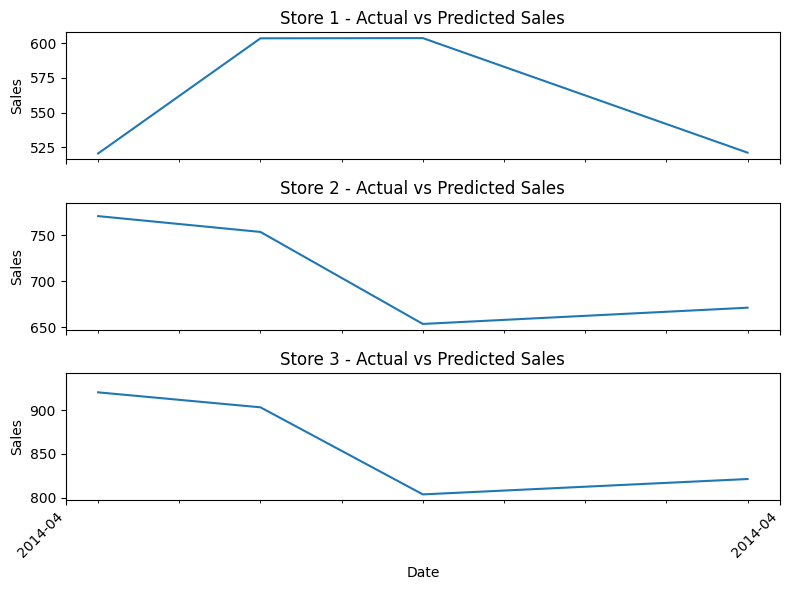

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

actual = df['Sales']

def plot_actual_vs_predicted(actual, preds):
        
    stores = actual.index.get_level_values("Store").unique()
    fig, ax = plt.subplots(figsize=(8, 6), nrows=len(stores), sharex=True, sharey=False)

    for i, store in enumerate(stores):

        actual_store_sales = (utils.retrieve_sales(actual, preds.index)
                            .loc[(slice(None), store)]
                            .sort_index())
        
        predicted_store_sales = (preds
                                .loc[(slice(None), store, slice(None))]
                                .reset_index())

        # exclude closed days with zero sales and zero predictions
        actual_store_sales = actual_store_sales[actual_store_sales > 0]
        predicted_store_sales = predicted_store_sales[predicted_store_sales[0] > 0]

        actual_store_sales.plot(label=f"Store {store}", ax=ax[i])
        (predicted_store_sales
        .groupby("Date")
        .plot(x="Forecast Date", y=0, ax=ax[i], color='k', linestyle='--', linewidth=1))

        ax[i].get_legend().remove()
        ax[i].set_title(f"Store {store} - Actual vs Predicted Sales")
        ax[i].set_ylabel("Sales")
        
    # Rotate x labels and set date format
    ax[-1].xaxis.set_major_locator(mdates.MonthLocator())
    ax[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)
    ax[-1].set_xlabel("Date")
    plt.tight_layout()

    return 

plot_actual_vs_predicted(actual, preds)